# Data Preparation

Load the dataset, inspect samples, and prepare training/validation splits.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wenewone/cub2002011")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cub2002011' dataset.
Path to dataset files: /kaggle/input/cub2002011


## 1. Dataset Inspection
This section examines the dataset folders and files before checking the image labels.


In [3]:
from pathlib import Path

# Convert the downloaded dataset path into a Path object
dataset_path = Path(path)

print("Dataset path:", dataset_path)
print("Dataset exists:", dataset_path.exists())

print("\nFiles and folders inside the dataset:")

for item in sorted(dataset_path.iterdir()):
    if item.is_dir():
        print("[Folder]", item.name)
    else:
        print("[File]", item.name)

Dataset path: /root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7
Dataset exists: True

Files and folders inside the dataset:
[Folder] CUB_200_2011
[Folder] cvpr2016_cub
[Folder] segmentations


In [4]:
# Select the main CUB-200-2011 dataset folder
DATASET_ROOT = dataset_path / "CUB_200_2011"
IMAGES_FOLDER = DATASET_ROOT / "images"

print("Dataset root:", DATASET_ROOT)
print("Images folder exists:", IMAGES_FOLDER.exists())

print("\nFiles and folders inside CUB_200_2011:")

for item in sorted(DATASET_ROOT.iterdir()):
    print("-", item.name)

Dataset root: /root/.cache/kagglehub/datasets/wenewone/cub2002011/versions/7/CUB_200_2011
Images folder exists: True

Files and folders inside CUB_200_2011:
- README
- attributes
- bounding_boxes.txt
- classes.txt
- image_class_labels.txt
- images
- images.txt
- parts
- train_test_split.txt


## 2. Check Dataset Labels

The dataset label files are loaded and compared with the image paths to verify that every image has a valid bird-species label.

In [5]:
import pandas as pd

# File containing class IDs and bird species names
classes = pd.read_csv(
    DATASET_ROOT / "classes.txt",
    sep=r"\s+",
    names=["class_id", "class_name"]
)

# File containing image IDs and image paths
images = pd.read_csv(
    DATASET_ROOT / "images.txt",
    sep=r"\s+",
    names=["image_id", "image_path"]
)

# File connecting every image ID to a class ID
image_labels = pd.read_csv(
    DATASET_ROOT / "image_class_labels.txt",
    sep=r"\s+",
    names=["image_id", "class_id"]
)

print("Number of classes:", len(classes))
print("Number of image records:", len(images))
print("Number of label records:", len(image_labels))

Number of classes: 200
Number of image records: 11788
Number of label records: 11788


In [6]:
print("First 10 bird classes:")
display(classes.head(10))

First 10 bird classes:


,class_id,class_name
0,1,001.Black_footed_Albatross
1,2,002.Laysan_Albatross
2,3,003.Sooty_Albatross
3,4,004.Groove_billed_Ani
4,5,005.Crested_Auklet
5,6,006.Least_Auklet
6,7,007.Parakeet_Auklet
7,8,008.Rhinoceros_Auklet
8,9,009.Brewer_Blackbird
9,10,010.Red_winged_Blackbird


In [7]:
# Combine image paths, class IDs and class names into one table
dataset_info = images.merge(
    image_labels,
    on="image_id",
    how="left"
)

dataset_info = dataset_info.merge(
    classes,
    on="class_id",
    how="left"
)

print("Combined dataset shape:", dataset_info.shape)

display(dataset_info.head(10))

Combined dataset shape: (11788, 4)


,image_id,image_path,class_id,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
5,6,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
6,7,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
7,8,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
8,9,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
9,10,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross


In [8]:
# Count missing values in each column
print("Missing values:")
print(dataset_info.isnull().sum())

# Check whether any image ID appears more than once
duplicate_image_ids = dataset_info["image_id"].duplicated().sum()

# Check whether any image path appears more than once
duplicate_image_paths = dataset_info["image_path"].duplicated().sum()

# Check whether class IDs are within the correct range
invalid_class_ids = dataset_info[
    ~dataset_info["class_id"].between(1, 200)
]

print("\nDuplicate image IDs:", duplicate_image_ids)
print("Duplicate image paths:", duplicate_image_paths)
print("Invalid class IDs:", len(invalid_class_ids))

Missing values:
image_id      0
image_path    0
class_id      0
class_name    0
dtype: int64

Duplicate image IDs: 0
Duplicate image paths: 0
Invalid class IDs: 0


In [9]:
from pathlib import Path

# Extract the folder name from each image path
# Example:
# 001.Black_footed_Albatross/image_001.jpg
# becomes:
# 001.Black_footed_Albatross

dataset_info["folder_name"] = dataset_info["image_path"].apply(
    lambda image_path: Path(image_path).parts[0]
)

# Find rows where the folder name and official class name do not match
label_mismatches = dataset_info[
    dataset_info["folder_name"] != dataset_info["class_name"]
]

print("Total images checked:", len(dataset_info))
print("Folder-label mismatches:", len(label_mismatches))

if len(label_mismatches) == 0:
    print("Result: All image folders match their official class labels.")
else:
    print("Images with mismatched labels:")
    display(label_mismatches.head(10))

Total images checked: 11788
Folder-label mismatches: 0
Result: All image folders match their official class labels.


In [10]:
# Create the complete path for every image
dataset_info["full_image_path"] = dataset_info["image_path"].apply(
    lambda image_path: IMAGES_FOLDER / image_path
)

# Check whether every listed image exists
dataset_info["file_exists"] = dataset_info["full_image_path"].apply(
    lambda image_path: image_path.exists()
)

missing_image_files = dataset_info[
    dataset_info["file_exists"] == False
]

print("Images listed in metadata:", len(dataset_info))
print("Existing image files:", dataset_info["file_exists"].sum())
print("Missing image files:", len(missing_image_files))

if len(missing_image_files) == 0:
    print("Result: Every image listed in the metadata exists.")
else:
    display(missing_image_files.head(10))

Images listed in metadata: 11788
Existing image files: 11788
Missing image files: 0
Result: Every image listed in the metadata exists.


### Label Verification Conclusion

The dataset contains 200 bird-species classes and 11,788 image records. No missing labels, duplicate image IDs, duplicate image paths, or invalid class IDs were found. The image folder names were also compared with the official class names, and the existence of every listed image file was verified.

## 3. Detect Corrupted and Duplicate Images

Each image is opened and verified to identify corrupted or unreadable files. Exact duplicate images are detected using their file hashes. The original dataset is preserved, and invalid or duplicate records are excluded from a clean dataset table.

In [11]:
from PIL import Image
from tqdm.auto import tqdm

def validate_image(image_path):
    """
    Check whether an image can be opened, verified and converted to RGB.
    """
    try:
        # Verify the image file structure
        with Image.open(image_path) as image:
            image.verify()

        # Open it again and check that pixel data can be loaded
        with Image.open(image_path) as image:
            image.convert("RGB").load()

        return True, ""

    except Exception as error:
        return False, str(error)


validation_results = []

for image_path in tqdm(
    dataset_info["full_image_path"],
    desc="Checking image files"
):
    is_valid, error_message = validate_image(image_path)

    validation_results.append({
        "is_valid_image": is_valid,
        "validation_error": error_message
    })

validation_results = pd.DataFrame(validation_results)

dataset_info["is_valid_image"] = validation_results["is_valid_image"]
dataset_info["validation_error"] = validation_results["validation_error"]

corrupted_images = dataset_info[
    dataset_info["is_valid_image"] == False
]

print("Total images checked:", len(dataset_info))
print("Valid images:", dataset_info["is_valid_image"].sum())
print("Corrupted or unreadable images:", len(corrupted_images))

if len(corrupted_images) == 0:
    print("Result: No corrupted images were found.")
else:
    display(
        corrupted_images[
            ["image_id", "image_path", "class_name", "validation_error"]
        ].head(10)
    )

Checking image files:   0%|          | 0/11788 [00:00<?, ?it/s]

Total images checked: 11788
Valid images: 11788
Corrupted or unreadable images: 0
Result: No corrupted images were found.


In [12]:
import hashlib

def calculate_file_hash(image_path, chunk_size=8192):
    """
    Calculate a SHA-256 hash from the image file contents.
    Identical files will produce the same hash.
    """
    sha256 = hashlib.sha256()

    with open(image_path, "rb") as image_file:
        while True:
            data = image_file.read(chunk_size)

            if not data:
                break

            sha256.update(data)

    return sha256.hexdigest()


image_hashes = []

for image_path, is_valid in tqdm(
    zip(
        dataset_info["full_image_path"],
        dataset_info["is_valid_image"]
    ),
    total=len(dataset_info),
    desc="Calculating image hashes"
):
    if is_valid:
        image_hashes.append(calculate_file_hash(image_path))
    else:
        image_hashes.append(None)

dataset_info["file_hash"] = image_hashes

# Keep the first copy and mark later identical files as duplicates
dataset_info["is_exact_duplicate"] = (
    dataset_info["file_hash"].notna()
    & dataset_info["file_hash"].duplicated(keep="first")
)

duplicate_images = dataset_info[
    dataset_info["is_exact_duplicate"] == True
]

print("Total valid images:", dataset_info["is_valid_image"].sum())
print("Exact duplicate images:", len(duplicate_images))

if len(duplicate_images) == 0:
    print("Result: No exact duplicate images were found.")
else:
    print("Duplicate images that will be excluded:")
    display(
        duplicate_images[
            ["image_id", "image_path", "class_name", "file_hash"]
        ].head(10)
    )

Calculating image hashes:   0%|          | 0/11788 [00:00<?, ?it/s]

Total valid images: 11788
Exact duplicate images: 1
Duplicate images that will be excluded:


,image_id,image_path,class_name,file_hash
3339,3340,058.Pigeon_Guillemot/Pigeon_Guillemot_0081_403...,058.Pigeon_Guillemot,96c64ec1d30fa7071f3809feea6caadd89b941ea5cbcde...


In [13]:
clean_dataset_info = dataset_info[
    (dataset_info["is_valid_image"] == True)
    & (dataset_info["is_exact_duplicate"] == False)
].copy()

clean_dataset_info.reset_index(drop=True, inplace=True)

removed_corrupted = len(
    dataset_info[dataset_info["is_valid_image"] == False]
)

removed_duplicates = len(
    dataset_info[dataset_info["is_exact_duplicate"] == True]
)

print("Original number of images:", len(dataset_info))
print("Corrupted images excluded:", removed_corrupted)
print("Duplicate images excluded:", removed_duplicates)
print("Clean dataset size:", len(clean_dataset_info))

Original number of images: 11788
Corrupted images excluded: 0
Duplicate images excluded: 1
Clean dataset size: 11787


In [14]:
# Get the hash values that appear more than once
duplicate_hashes = dataset_info.loc[
    dataset_info["file_hash"].duplicated(keep=False),
    "file_hash"
].unique()

# Display every image sharing a duplicate hash
duplicate_groups = dataset_info[
    dataset_info["file_hash"].isin(duplicate_hashes)
][
    ["image_id", "image_path", "class_id", "class_name", "file_hash"]
].sort_values("file_hash")

print("Number of duplicate groups:", len(duplicate_hashes))
print("Images involved in duplicate groups:", len(duplicate_groups))

display(duplicate_groups)

Number of duplicate groups: 1
Images involved in duplicate groups: 2


,image_id,image_path,class_id,class_name,file_hash
3309,3310,058.Pigeon_Guillemot/Pigeon_Guillemot_0018_401...,58,058.Pigeon_Guillemot,96c64ec1d30fa7071f3809feea6caadd89b941ea5cbcde...
3339,3340,058.Pigeon_Guillemot/Pigeon_Guillemot_0081_403...,58,058.Pigeon_Guillemot,96c64ec1d30fa7071f3809feea6caadd89b941ea5cbcde...


In [15]:
duplicate_class_check = (
    duplicate_groups
    .groupby("file_hash")["class_id"]
    .nunique()
)

cross_class_duplicates = duplicate_class_check[
    duplicate_class_check > 1
]

print(
    "Duplicate groups containing images from different classes:",
    len(cross_class_duplicates)
)

if len(cross_class_duplicates) == 0:
    print("Result: The duplicate images belong to the same bird class.")
else:
    print("Warning: An identical image appears under different class labels.")

Duplicate groups containing images from different classes: 0
Result: The duplicate images belong to the same bird class.


### Image Quality and Duplicate Check Conclusion

All 11,788 dataset images were opened and verified successfully, and no corrupted or unreadable images were detected. SHA-256 file hashes identified one exact duplicate image. The duplicate was excluded from the clean dataset table without modifying the original dataset. Therefore, the clean dataset contains 11,787 valid and unique images.

## 4. Class Distribution and Balance

The number of clean images in each bird-species class is examined to determine whether class balancing is necessary. Balancing will only be applied if there is a meaningful difference between class sizes.

In [16]:
# Count valid and unique images in each bird class
class_distribution = (
    clean_dataset_info
    .groupby(["class_id", "class_name"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count")
)

minimum_count = class_distribution["image_count"].min()
maximum_count = class_distribution["image_count"].max()
average_count = class_distribution["image_count"].mean()
imbalance_ratio = maximum_count / minimum_count

print("Number of classes:", len(class_distribution))
print("Minimum images in one class:", minimum_count)
print("Maximum images in one class:", maximum_count)
print("Average images per class:", round(average_count, 2))
print("Imbalance ratio:", round(imbalance_ratio, 3))

print("\nClasses with the fewest images:")
display(class_distribution.head(10))

print("\nClasses with the most images:")
display(class_distribution.tail(10))

Number of classes: 200
Minimum images in one class: 41
Maximum images in one class: 60
Average images per class: 58.94
Imbalance ratio: 1.463

Classes with the fewest images:


,class_id,class_name,image_count
5,6,006.Least_Auklet,41
4,5,005.Crested_Auklet,44
17,18,018.Spotted_Catbird,45
7,8,008.Rhinoceros_Auklet,48
104,105,105.Whip_poor_Will,49
112,113,113.Baird_Sparrow,50
64,65,065.Slaty_backed_Gull,50
100,101,101.White_Pelican,50
186,187,187.American_Three_toed_Woodpecker,50
150,151,151.Black_capped_Vireo,51



Classes with the most images:


,class_id,class_name,image_count
190,191,191.Red_headed_Woodpecker,60
129,130,130.Tree_Sparrow,60
191,192,192.Downy_Woodpecker,60
192,193,193.Bewick_Wren,60
193,194,194.Cactus_Wren,60
194,195,195.Carolina_Wren,60
196,197,197.Marsh_Wren,60
197,198,198.Rock_Wren,60
198,199,199.Winter_Wren,60
199,200,200.Common_Yellowthroat,60


In [17]:
# Show how many classes have each possible number of images
count_frequency = (
    class_distribution["image_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

count_frequency.columns = [
    "images_per_class",
    "number_of_classes"
]

display(count_frequency)

,images_per_class,number_of_classes
0,41,1
1,44,1
2,45,1
3,48,1
4,49,1
5,50,4
6,51,1
7,52,1
8,53,3
9,56,3


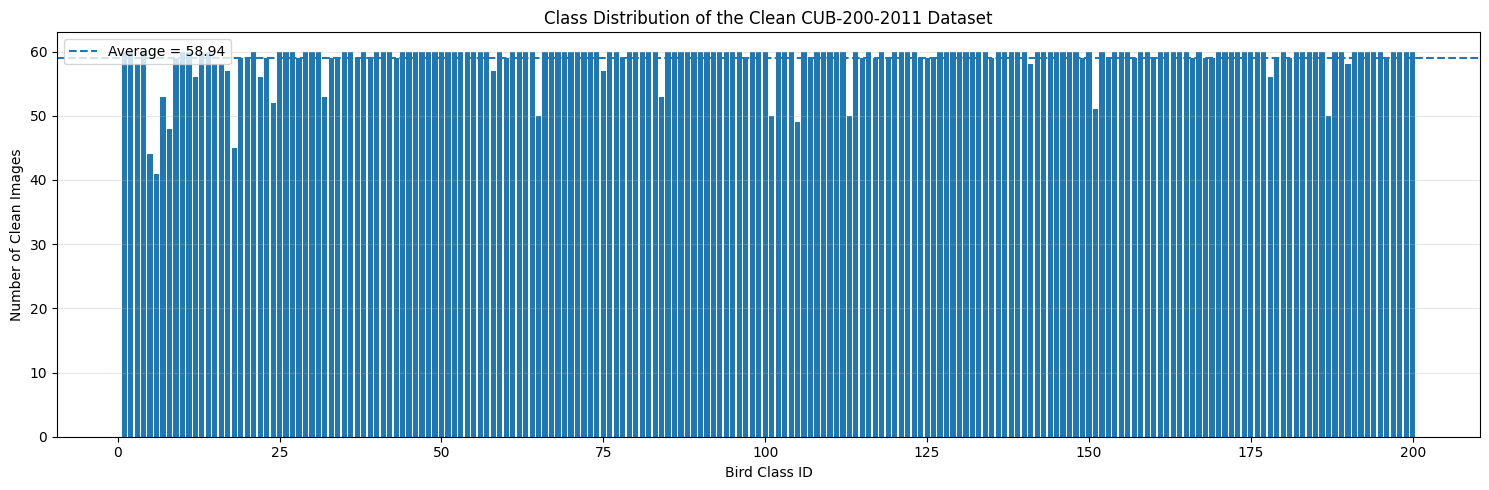

In [18]:
import matplotlib.pyplot as plt

plot_distribution = class_distribution.sort_values("class_id")

plt.figure(figsize=(15, 5))

plt.bar(
    plot_distribution["class_id"],
    plot_distribution["image_count"]
)

plt.axhline(
    average_count,
    linestyle="--",
    label=f"Average = {average_count:.2f}"
)

plt.xlabel("Bird Class ID")
plt.ylabel("Number of Clean Images")
plt.title("Class Distribution of the Clean CUB-200-2011 Dataset")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# A ratio close to 1 means that the classes have similar sizes.
# We avoid balancing when the difference is small because undersampling
# would unnecessarily discard useful images.

if imbalance_ratio <= 1.5:
    balancing_required = False

    print("Balancing required: No")
    print(
        "Reason: The class sizes are sufficiently similar, "
        "so balancing would unnecessarily remove useful images."
    )
    print(
        "Decision: Keep all clean images and use a stratified "
        "training/testing split later."
    )
else:
    balancing_required = True

    print("Balancing required: Yes")
    print(
        "Reason: There is a considerable difference between "
        "the smallest and largest classes."
    )

Balancing required: No
Reason: The class sizes are sufficiently similar, so balancing would unnecessarily remove useful images.
Decision: Keep all clean images and use a stratified training/testing split later.


In [20]:
# No resampling is performed when the dataset is sufficiently balanced.
# The cleaned dataset becomes the final prepared dataset.

if not balancing_required:
    final_dataset_info = clean_dataset_info.copy()
else:
    # Keep the clean dataset temporarily.
    # A balancing method should only be chosen after team agreement.
    final_dataset_info = clean_dataset_info.copy()

final_dataset_info.reset_index(drop=True, inplace=True)

print("Clean dataset size:", len(clean_dataset_info))
print("Final prepared dataset size:", len(final_dataset_info))
print("Number of final classes:", final_dataset_info["class_id"].nunique())

Clean dataset size: 11787
Final prepared dataset size: 11787
Number of final classes: 200


## 5. Alternative Dataset Download (Direct from Caltech)

The cells below provide an alternative way to download the CUB-200-2011 dataset
directly from the Caltech server without using `kagglehub`. This approach can
be useful when `kagglehub` is unavailable or when running outside of Kaggle
or Colab environments.

In [ ]:
import os
import tarfile

# Direct download URL from the Caltech data repository
DATASET_URL = "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz"
TAR_PATH    = "CUB_200_2011.tgz"
EXTRACT_DIR = "./raw_cub"

# Download the archive only if it has not been downloaded already
if not os.path.exists(TAR_PATH):
    import urllib.request
    print("Downloading CUB-200-2011 from Caltech server...")
    urllib.request.urlretrieve(DATASET_URL, TAR_PATH)
    print("Download complete.")
else:
    print("Archive already present, skipping download.")

# Extract the archive if the target directory does not exist yet
if not os.path.exists(EXTRACT_DIR):
    print("Extracting archive...")
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        tar.extractall(path=EXTRACT_DIR)
    print("Extraction complete.")
else:
    print("Dataset already extracted, skipping extraction.")

print("Dataset location:", os.path.join(EXTRACT_DIR, "CUB_200_2011"))

## 6. Build a 20-Species Subset

A smaller subset containing only the first 20 bird species is assembled from
the full dataset. This subset is useful for rapid prototyping and model
iteration without processing all 200 classes.

In [ ]:
import shutil

# Source folder containing all species sub-folders
SOURCE_IMAGES_PATH = os.path.join(EXTRACT_DIR, "CUB_200_2011", "images")
SUBSET_DIR         = "./dataset_20_species"

# Remove any existing subset directory and start fresh
if os.path.exists(SUBSET_DIR):
    shutil.rmtree(SUBSET_DIR)
os.makedirs(SUBSET_DIR)

# Copy the first 20 species folders (sorted alphabetically)
species_folders = sorted(os.listdir(SOURCE_IMAGES_PATH))
selected_species = species_folders[:20]

for species in selected_species:
    src = os.path.join(SOURCE_IMAGES_PATH, species)
    dst = os.path.join(SUBSET_DIR, species)
    if os.path.isdir(src):
        shutil.copytree(src, dst)

print(f"20-species subset created at: {SUBSET_DIR}")
print(f"Species included: {len(selected_species)}")
for species in selected_species:
    print(f"  - {species}")

## 7. Per-Species Image Count (20-Species Subset)

The number of images in each species folder of the 20-species subset is
displayed in a formatted table for a quick sanity check.

In [ ]:
# Display a formatted table of image counts per species
print(f"{'Species Folder Name':<35} | {'Image Count'}")
print("-" * 52)

total_images = 0

for species in sorted(os.listdir(SUBSET_DIR)):
    species_path = os.path.join(SUBSET_DIR, species)
    if not os.path.isdir(species_path):
        continue

    # Count only recognised image file extensions
    image_count = sum(
        1 for file in os.listdir(species_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    )
    total_images += image_count
    print(f"{species:<35} | {image_count}")

print("-" * 52)
print(f"{'TOTAL':<35} | {total_images}")

In [1]:
# Keep only portable columns.
# Do not save full_image_path because it contains a temporary Colab path.

columns_to_save = [
    "image_id",
    "image_path",
    "class_id",
    "class_name"
]

prepared_metadata = final_dataset_info[
    columns_to_save
].copy()

output_file = "/content/clean_dataset_metadata.csv"
prepared_metadata.to_csv(output_file, index=False)

print("Metadata saved to:", output_file)
print("Saved rows:", len(prepared_metadata))

display(prepared_metadata.head())

NameError: name 'final_dataset_info' is not defined

### Class-Balance Conclusion

The clean dataset contains 200 bird-species classes. The class-distribution analysis showed that the class sizes are sufficiently similar and that no substantial imbalance is present. Therefore, no undersampling or oversampling was applied, because it could remove useful observations or introduce repeated data. All 11,787 valid and unique images were retained. A stratified training and testing split will be used later to preserve class representation.